<a href="https://colab.research.google.com/github/Nibble0/multiclass-classification/blob/main/notebooks/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muratkokludataset/dry-bean-dataset")

print("Path to dataset files:", path)

import os

arquivo = os.path.join(
    path,
    "Dry_Bean_Dataset",
    "Dry_Bean_Dataset.xlsx"
)

df = pd.read_excel(arquivo)

Using Colab cache for faster access to the 'dry-bean-dataset' dataset.
Path to dataset files: /kaggle/input/dry-bean-dataset


In [19]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

display(df.head())

Linhas: 13611
Colunas: 17


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [21]:
missing_values = df.isnull().sum()

display(missing_values)

,0
Area,0
Perimeter,0
MajorAxisLength,0
MinorAxisLength,0
AspectRation,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Solidity,0


In [22]:
duplicates = df.duplicated().sum()

print(f"Registros duplicados: {duplicates}")

Registros duplicados: 68


In [23]:
df[df.duplicated()].head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
5505,33518,702.956,277.571399,154.305581,1.798842,0.831240,34023,206.582775,0.808383,0.985157,0.852377,0.744251,0.008281,0.001567,0.553909,0.996396,HOROZ
5509,33954,716.750,277.368480,156.356326,1.773951,0.825970,34420,207.922042,0.799482,0.986461,0.830549,0.749624,0.008169,0.001591,0.561936,0.996847,HOROZ
5548,38427,756.323,306.533886,160.591784,1.908777,0.851782,38773,221.193978,0.796976,0.991076,0.844174,0.721597,0.007977,0.001334,0.520702,0.993905,HOROZ
5554,38891,791.343,319.499996,156.869619,2.036723,0.871168,39651,222.525412,0.650025,0.980833,0.780422,0.696480,0.008215,0.001192,0.485085,0.987983,HOROZ
5599,40804,790.802,323.475648,163.287717,1.981016,0.863241,41636,227.932592,0.787570,0.980017,0.819931,0.704636,0.007928,0.001206,0.496512,0.983598,HOROZ


In [24]:
df[df.duplicated()].shape

(68, 17)

Posso concluir que os dados duplicados não terão um impacto muito significante, por isso, optarei por mante-las.

In [25]:
df["Class"].value_counts()

,count
Class,
DERMASON,3546
SIRA,2636
SEKER,2027
HOROZ,1928
CALI,1630
BARBUNYA,1322
BOMBAY,522


Desbalanceamento de dados significativo (Moderado)

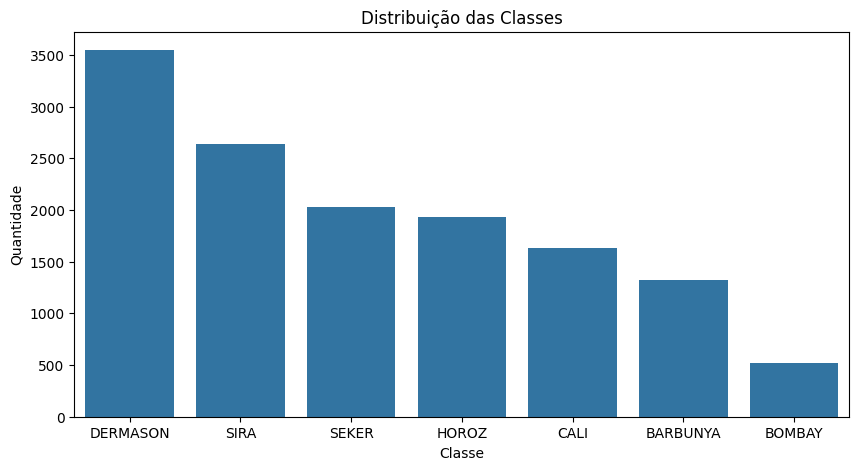

In [26]:
# Distribuição das Classes
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Class",
    order=df["Class"].value_counts().index
)

plt.title("Distribuição das Classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade")

plt.show()

In [27]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


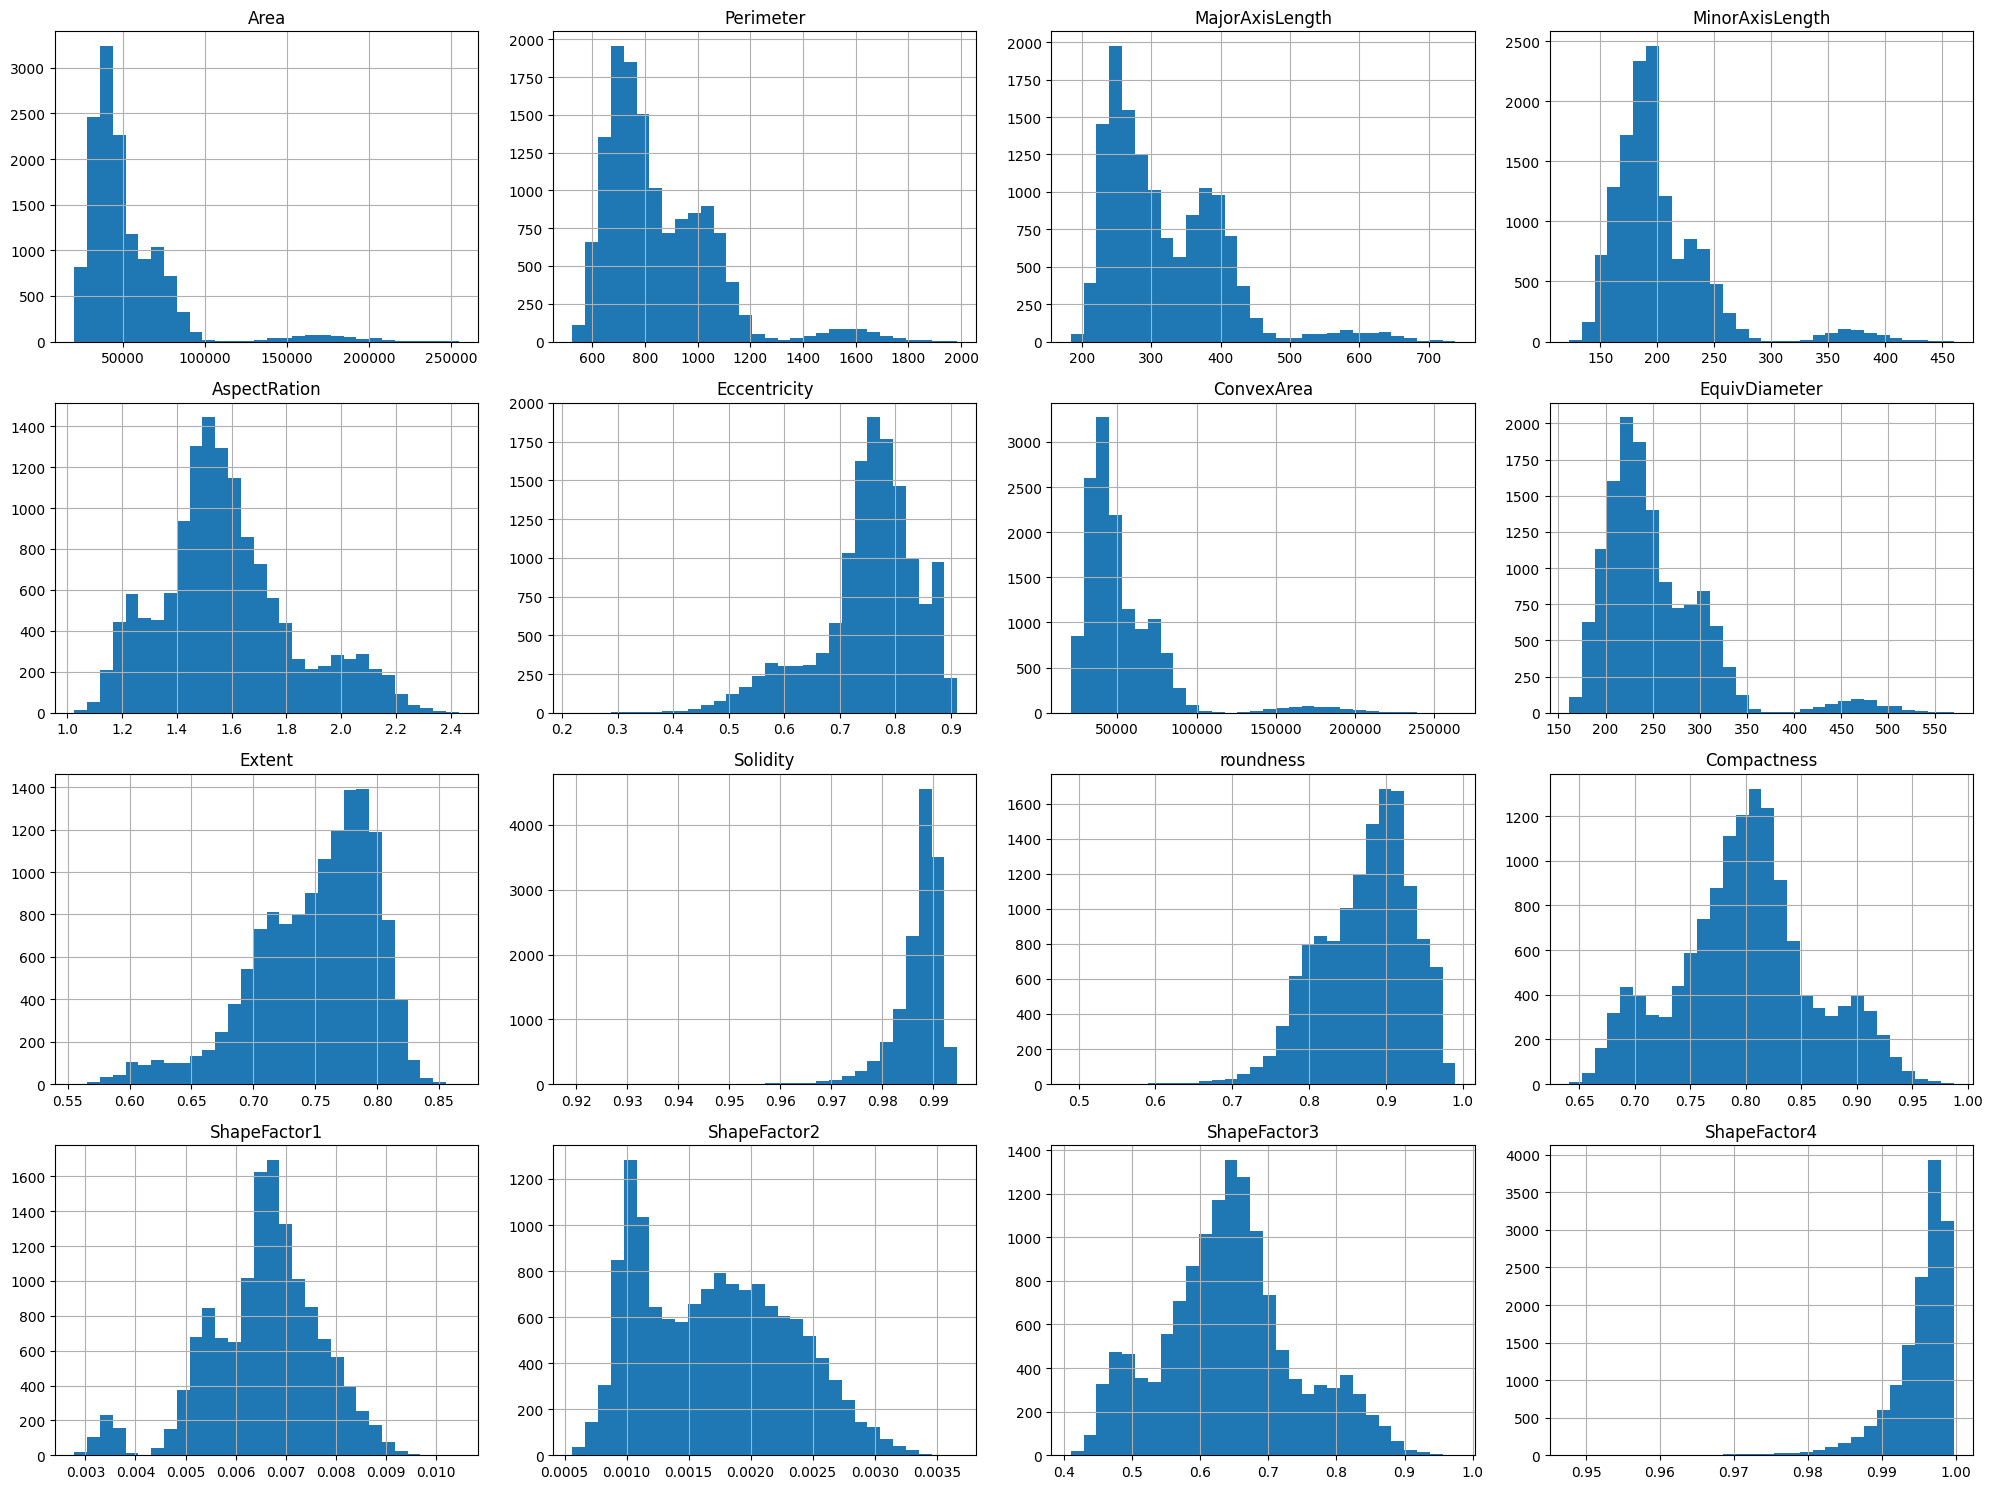

In [28]:
#Histogramas
df.hist(
    figsize=(20,15),
    bins=30
)

plt.tight_layout()
plt.show()

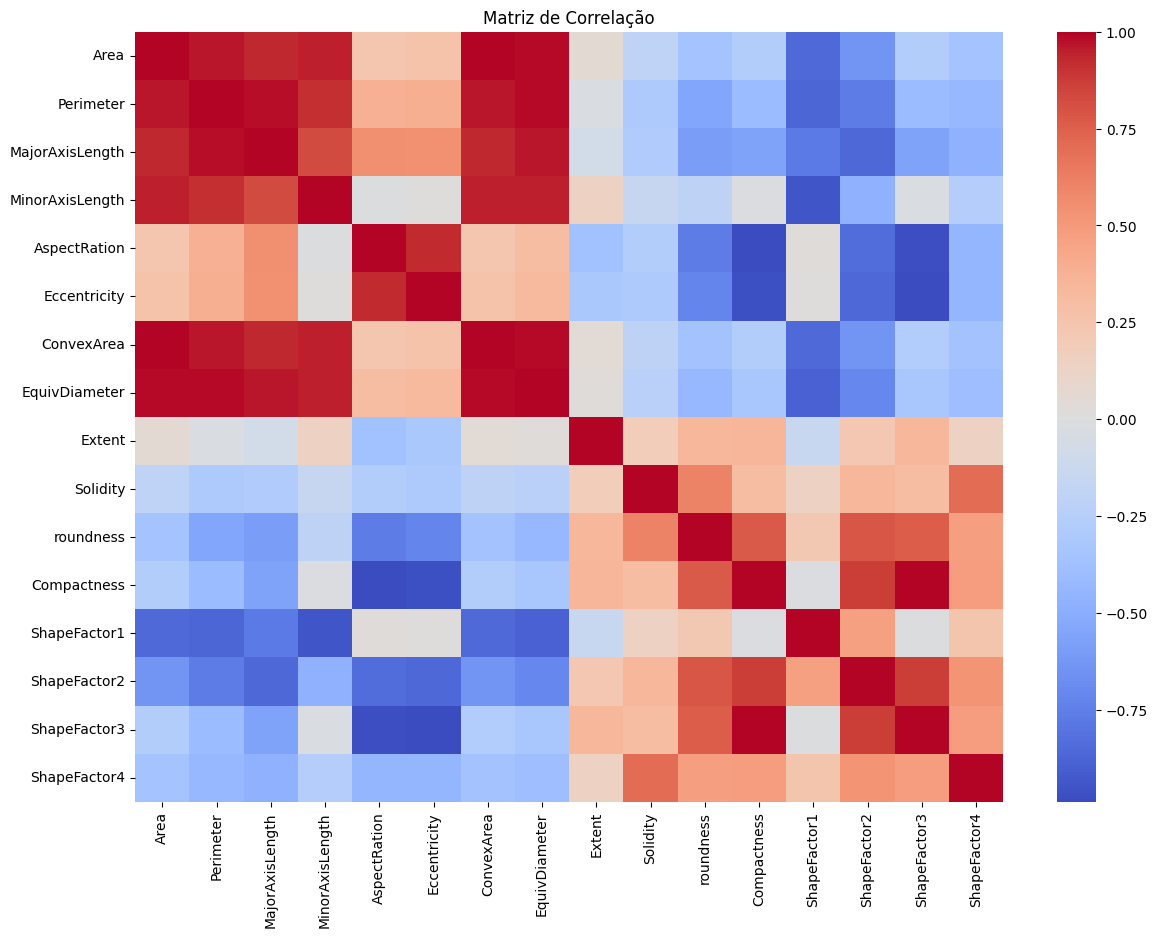

In [29]:
#heatmap
plt.figure(figsize=(14,10))

corr = df.drop("Class", axis=1).corr()

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Matriz de Correlação")

plt.show()

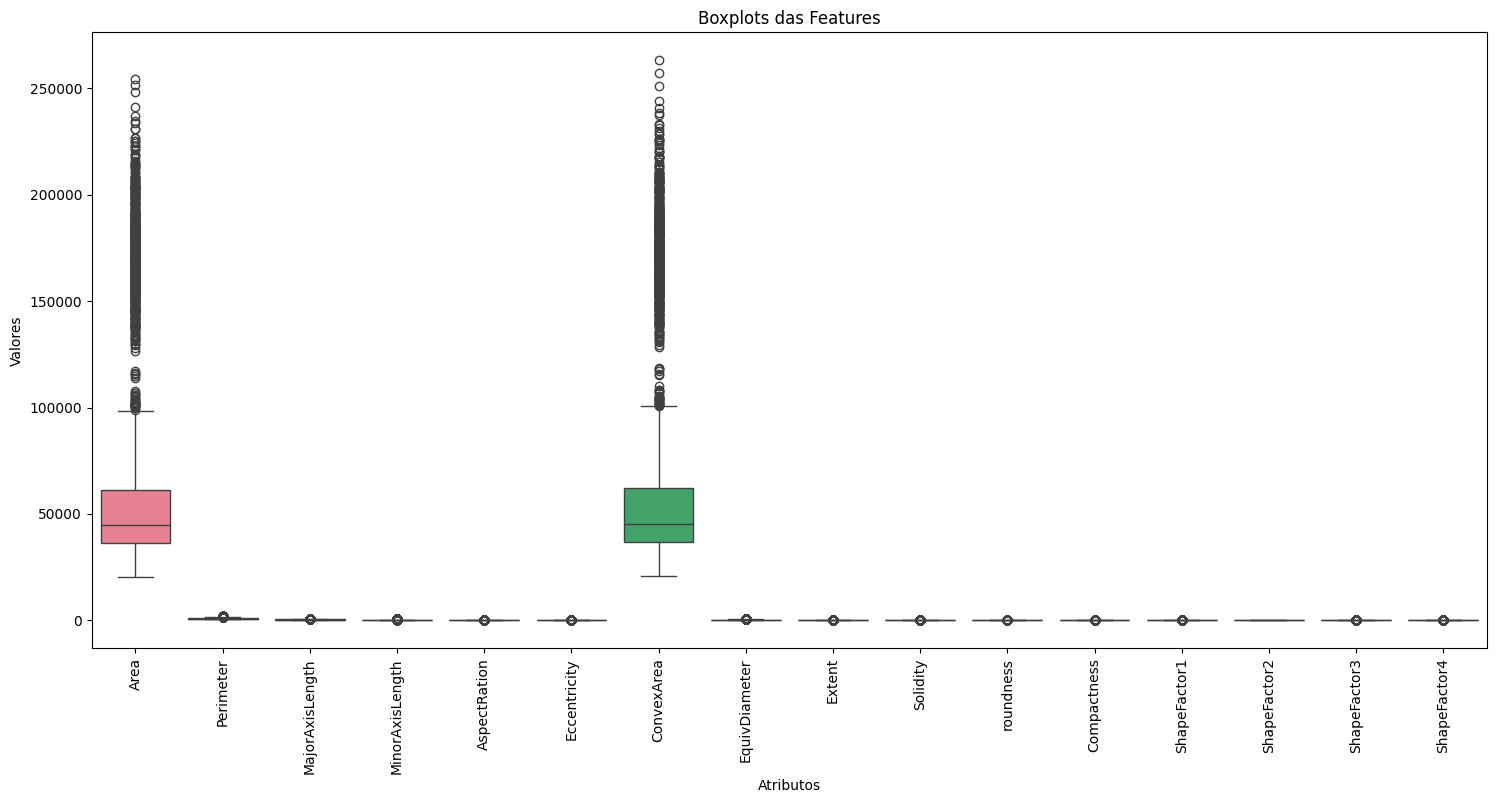

In [30]:
plt.figure(figsize=(18,8))

sns.boxplot(data=df.drop("Class", axis=1))

plt.xticks(rotation=90)
plt.title("Boxplots das Features")
plt.xlabel("Atributos")
plt.ylabel("Valores")

plt.show()

Montagem do PCA

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [32]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [33]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [34]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [35]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Class"] = y.values

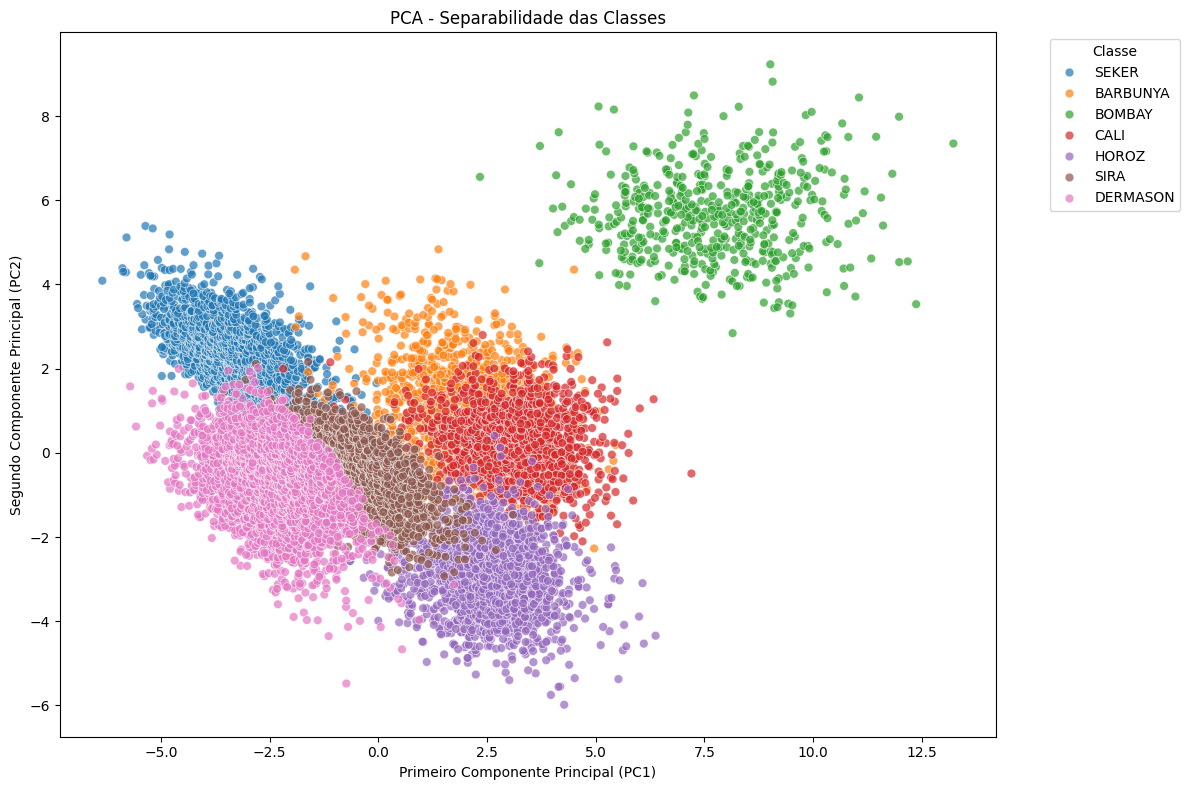

In [36]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Class",
    alpha=0.7,
    s=40
)

plt.title("PCA - Separabilidade das Classes")
plt.xlabel("Primeiro Componente Principal (PC1)")
plt.ylabel("Segundo Componente Principal (PC2)")

plt.legend(title="Classe", bbox_to_anchor=(1.05, 1))
plt.tight_layout()

plt.show()

In [37]:
print("Variância explicada pelos componentes:")

for i, var in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"PC{i}: {var:.2%}")

print(
    f"\nTotal explicado: {sum(pca.explained_variance_ratio_):.2%}"
)

Variância explicada pelos componentes:
PC1: 55.47%
PC2: 26.43%

Total explicado: 81.90%


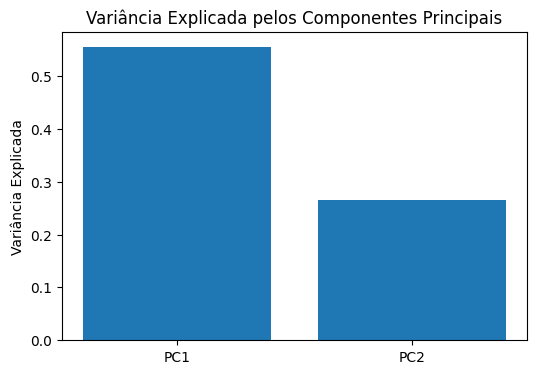

In [38]:
plt.figure(figsize=(6,4))

plt.bar(
    ["PC1", "PC2"],
    pca.explained_variance_ratio_
)

plt.ylabel("Variância Explicada")
plt.title("Variância Explicada pelos Componentes Principais")

plt.show()